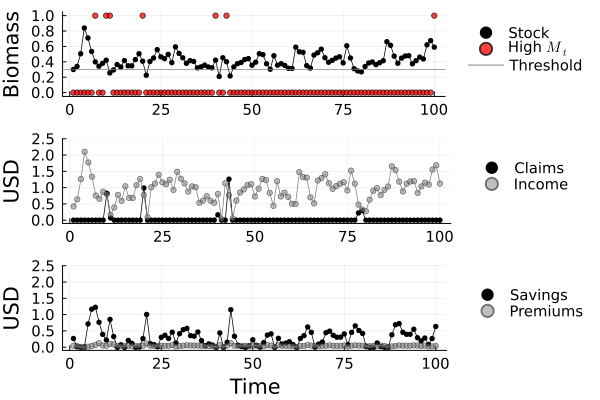

In [18]:

using Pkg, Random, Plots
#Pkg.activate("../.")
include("../src/model.jl")
include("../parameters/$pars.jl")

# Set up quadrature 
X, Xmc = init_ranom_variables(p;Nquad = 15)

# Define state grid to set up problem 
bmax = 0.25; bmin = -3.5; Nb_grid = 12
b_grid = bmin:((bmax-bmin)/(Nb_grid-1)):bmax
Δbmax = 1.25; Δbmin = -1.0; NΔb_grid = 7
Δb_grid = Δbmin:((Δbmax-Δbmin)/(NΔb_grid-1)):Δbmax
smax = 2.5; smin = -4.0; Ns_grid = 10
s_grid = smin:((smax-smin)/(Ns_grid-1)):smax
state_grid = [s_grid,b_grid,Δb_grid]

# Define action grid
κmin = 0.01; κmax = 0.99; Nκ = 30
κ_grid = κmin:((κmax-κmin)/(Nκ-1)):κmax
ηmin = 0.0; ηmax=0.2; Nη = 30
η_grid = ηmin:((ηmax-ηmin)/(Nη-1)):ηmax
action_grid = [κ_grid,η_grid]

# Define strike and index functions 
function strike(s,p)
    return 0.5*(p.b_target +p.b_limit) 
end

function index(s,X)
    return exp(s[1])+X[1]
end 

# Setup problem 
δ = 0.95
prob, El = init(action_grid,state_grid,δ,p,X,index,strike)

# Load in solution 
load_solution(prob,"../results/$pars/sol.jld2")

# load in plotting 
include("../src/plotting.jl")

# Set seed
# seed: 331, seed: 361, seed: 524, and seed: 232;, seed = 623; T = 100
Random.seed!(232)
x=simulation(prob,El,Xmc,101;with_policy = false, s0 = [1.0,0.0,log(0.3),0.0,1.0])
plot_simulation(x,max_USD=2.5,max_Bt=1.0,T = 100)

In [ ]:
keys(x)

(:Ibt, :st, :bt, :bt1, :κt, :ηt, :Elt, :η̄t, :Zt, :Zct, :wt, :ft, :mt, :ht, :pt, :c_et, :yt)

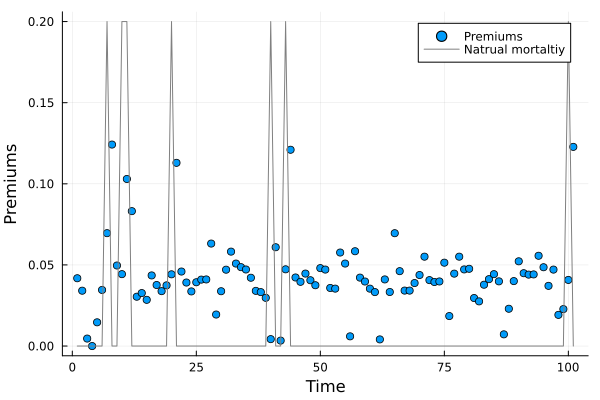

In [30]:
Plots.scatter(x.ηt, label = "Premiums")
Plots.plot!(0.2*(x.mt .> 0.75), color = "grey", label = "Natrual mortaltiy",
xlabel = "Time", ylabel = "Premiums")


In [17]:
# Set parameters 
pars = "RA_andre_pcod"

"RA_andre_pcod"

In [5]:
pars

"RA_andre_pcod"

In [8]:
m̄

0.46